# Прогноз общей суммы импорта РФ на t+1 период вперед.

## 0. Импорт библиотек.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import pmdarima as pm
from pandas.tseries.offsets import MonthBegin
from tqdm import tqdm
import datetime as dt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
import optuna
from sklearn.model_selection import TimeSeriesSplit
from optuna import Trial
from optuna.samplers import TPESampler

## 1. Модель

In [ ]:
class Model:
    def __init__(self, target_period, train_start, train_end):
        # Параметры модели
        self.target_period = self._to_ms(target_period)
        self.train_start = pd.Timestamp(train_start)
        self.train_end = pd.Timestamp(train_end)

        self.y_train = None
        self.stl_res = None
        self.y_train_adj = None
        self.X_train = None
        self.X_fore = None
        self.model = None

    @staticmethod
    # Месячная частотность
    def _to_ms(x):
        if isinstance(x, pd.Period):
            return x.asfreq("M").to_timestamp(how="start")
        ts = pd.to_datetime(x, errors="coerce")
        if pd.isna(ts):
            raise ValueError(f"Не удалось распарсить target_period='{x}'")
        return ts.to_period("M").to_timestamp(how="start")

    @staticmethod
    # Создание лагов
    def _lag_df(df: pd.DataFrame, spec: dict) -> pd.DataFrame:
        out = {}
        for name, lags in spec.items():
            for L in lags:
                out[f"{name}_L{L}"] = df[name].shift(L)
        return pd.DataFrame(out, index=df.index)

    # Данные ЦБ РФ
    def make_real(self) -> pd.Series:
        # В data ДОЛЖЕН ХРАНИТЬСЯ СВЕЖИЙ ФАЙЛ
        real = pd.read_excel("./data/real.xls")
        real = real.iloc[6:]
        real = real[[real.columns[0], real.columns[8]]].dropna()
        real.columns = ['period', 'value']
        real['month'] = real.groupby('period').cumcount() + 1
        real['period'] = pd.to_datetime(
            real['period'].astype(str) + '-' + real['month'].astype(str).str.zfill(2),
            format="%Y-%m"
        )
        real = real[real['period'].dt.date >= dt.date(2021, 1, 1)]
        s = real.set_index('period')['value']
        s.index = s.index.to_period("M").to_timestamp(how="start")
        s = s.asfreq("MS")
        if s.dtype == 'object':
            s = pd.to_numeric(s.astype(str).str.replace(' ', '', regex=False)
                                    .str.replace(',', '.', regex=False), errors='coerce')
        s = s.astype('float64')
        return s
    

    def make_log_diff(self) -> pd.Series:
        # В data ДОЛЖЕН ХРАНИТЬСЯ СВЕЖИЙ ФАЙЛ
        real = pd.read_excel("./data/real.xls")
        real = real.iloc[6:]
        real = real[[real.columns[0], real.columns[8]]].dropna()
        real.columns = ['period', 'value']
        real['month'] = real.groupby('period').cumcount() + 1
        real['period'] = pd.to_datetime(
            real['period'].astype(str) + '-' + real['month'].astype(str).str.zfill(2),
            format="%Y-%m"
        )
        real = real[real['period'].dt.date >= dt.date(2020, 12, 1)]
        s = real.set_index('period')['value']
        s.index = s.index.to_period("M").to_timestamp(how="start")
        s = s.asfreq("MS")
        if s.dtype == 'object':
            s = pd.to_numeric(s.astype(str).str.replace(' ', '', regex=False)
                                    .str.replace(',', '.', regex=False), errors='coerce')
        s = s.astype('float64')
        return np.log(s).diff()[1:]

    # Достаем ряд НДС
    def make_nds(self) -> pd.Series:
        # В data ДОЛЖЕН ХРАНИТЬСЯ СВЕЖИЙ ФАЙЛ
        nds = pd.read_excel("./data/nds.xlsx")
        nds.columns = nds.iloc[1]
        nds = nds[nds[nds.columns[1]] == "НДС на ввозимые товары"].iloc[:, 2:]
        nds = pd.melt(nds)
        nds.columns = ["month", "nds"]
        
        # ЗДЕСЬ НАДО ОБНОВЛЯТЬ ПО СВЕЖЕЙ СТРУКТУРЕ НДС
        map_fix = {
            "янв.23 ***": dt.datetime(2023, 1, 1),
            "фев.23 ***": dt.datetime(2023, 2, 1),
            "апр.24 ***": dt.datetime(2024, 4, 1),
            "июн.24 ***": dt.datetime(2024, 6, 1),
            "сен.24 ***": dt.datetime(2024, 9, 1),
            "ноя.24 ***": dt.datetime(2024, 11, 1),
            "фев.25 ***": dt.datetime(2025, 2, 1),
            "июн.25 ***": dt.datetime(2025, 6, 1),
            "июл.25 **":  dt.datetime(2025, 7, 1),
            "авг.25 **":  dt.datetime(2025, 8, 1),
        }
        nds['month'] = pd.to_datetime(nds['month'].replace(map_fix), errors="coerce")
        nds['value'] = nds.groupby(nds['month'].dt.year)['nds'].diff()
        nds.loc[nds['month'].dt.month == 1, 'value'] = nds.loc[nds['month'].dt.month == 1, 'nds']

        s = nds.set_index('month')['value'].sort_index()
        s = s[s.index >= "2020-12-01"]

        if s.dtype == 'object':
            s = pd.to_numeric(s.astype(str).str.replace(' ', '', regex=False)
                                   .str.replace(',', '.', regex=False), errors='coerce')
        s = s.astype('float64')
        s = s.where(s > 0)
        s = np.log(s)

        cutoff = max(self.train_end, self.target_period)
        s = s[s.index <= cutoff]

        s.index = s.index.to_period("M").to_timestamp(how="start")
        s = s.asfreq("MS")
        return s.diff()[1:]

    # Формируем X_train с лагами экзогенных переменных
    def make_design(self):
        y = self.make_real()
        nds = self.make_nds()
        real = self.make_log_diff()

        base_idx = y.index.union(nds.index)
        base = pd.DataFrame(index=base_idx)
        base['log_NDS_diff'] = nds
        base['log_real_diff'] = real

        lag_spec = {"log_NDS_diff": [0, 1], 'log_real_diff': [1, 2]}
            
        X_all = self._lag_df(base, lag_spec)

        self.y_train = y
        self.X_train = X_all.loc[self.y_train.index].dropna()
        self.y_train = self.y_train.loc[self.X_train.index]

        full_idx = pd.date_range(self.y_train.index.min(), self.target_period, freq="MS")
        tmp = pd.DataFrame(index=full_idx)
        tmp['log_NDS_diff'] = nds.reindex(full_idx) 
        tmp['log_real_diff'] = real.reindex(full_idx) 

        X_future = self._lag_df(tmp, lag_spec)
        self.X_fore = X_future.loc[[self.target_period]]

    # Убираем сезонность
    def stl_deseason(self):
        stl = STL(self.y_train, period=12, robust=True)
        self.stl_res = stl.fit()
        self.y_train_adj = (self.y_train - self.stl_res.seasonal).dropna()
        self.X_train = self.X_train.loc[self.y_train_adj.index]

    # Подбор ARIMA с минимизацией MSE и AICc
    def fit(self):
        self.make_design()
        self.stl_deseason()
        self.model = pm.auto_arima(
            self.y_train_adj,
            X=self.X_train,
            seasonal=False, m=1,
            start_p=1, start_q=1, max_p=6, max_q=6,
            max_d=3,
            test='kpss',
            trace=False,
            error_action='ignore',
            suppress_warnings=True,
            stepwise=True,
            information_criterion="aicc",
            scoring="mse",
        )

    # Предсказание
    def predict(self) -> pd.DataFrame:
        if self.model is None:
            raise RuntimeError("Сначала вызовите .fit()")

        yhat_adj = float(self.model.predict(n_periods=1, X=self.X_fore))
        month_mean = self.stl_res.seasonal.groupby(self.stl_res.seasonal.index.month).mean()
        seas = float(month_mean[self.target_period.month])
        yhat = (yhat_adj + seas)

        return pd.DataFrame({"period": [self.target_period], "yhat": [yhat]})

    # Запуск
    def run(self) -> pd.DataFrame:
        self.fit()
        return self.predict()


In [3]:
# Прогноз остатка
def forcast(target, data_period):
    model = Model(target_period=target[:-3], train_start="2021-01-01", train_end=data_period)
    fc = model.run()
    return model.model, fc["yhat"]

## 2. Прогноз на историческом периоде

In [4]:
# Обучаем модели и прогнозируем на t+1 для periods
def practice(periods=["2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01", "2024-05-01", "2024-06-01", "2024-07-01", "2024-08-01", "2024-09-01", "2024-10-01", "2024-11-01", "2024-12-01", "2025-01-01", "2025-02-01", "2025-03-01", "2025-04-01", "2025-05-01", "2025-06-01", "2025-07-01", "2025-08-01"]):
    forcasts = {}
    models = {}
    for i in range(len(periods)):
        print(f"Прогноз на {periods[i]}")
        if i == 0:
            forc = forcast(periods[i], "2023-12-01")
        else:
            forc = forcast(periods[i], periods[i-1])
        models[periods[i]], forcasts[periods[i]] = forc[0], forc[1]
    
    forcasts = pd.DataFrame.from_dict(forcasts, orient='index')
    forcasts.index = pd.to_datetime(forcasts.index)
    return models, forcasts

models, forcasts = practice()

Прогноз на 2024-01-01
Прогноз на 2024-02-01
Прогноз на 2024-03-01
Прогноз на 2024-04-01
Прогноз на 2024-05-01
Прогноз на 2024-06-01
Прогноз на 2024-07-01
Прогноз на 2024-08-01
Прогноз на 2024-09-01
Прогноз на 2024-10-01
Прогноз на 2024-11-01
Прогноз на 2024-12-01
Прогноз на 2025-01-01
Прогноз на 2025-02-01
Прогноз на 2025-03-01
Прогноз на 2025-04-01
Прогноз на 2025-05-01
Прогноз на 2025-06-01
Прогноз на 2025-07-01
Прогноз на 2025-08-01


## 3. График факт против прогноза на историческом периоде

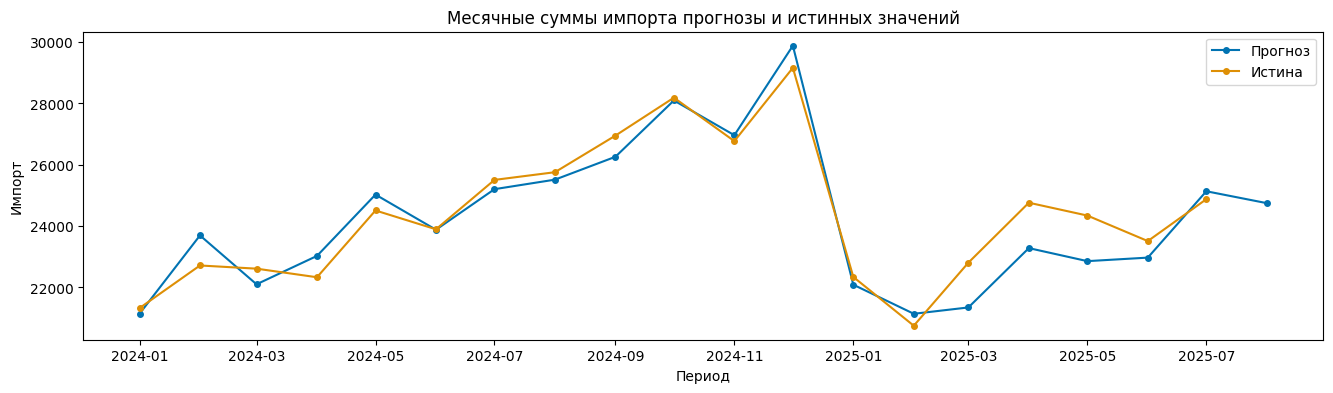

In [9]:
from sktime.utils.plotting import plot_series
import matplotlib.pyplot as plt

def make_real() -> pd.Series:
    real = pd.read_excel("./data/real.xls")
    real = real.iloc[6:]
    real = real[[real.columns[0], real.columns[8]]].dropna()
    real.columns = ['period', 'value']
    real['month'] = real.groupby('period').cumcount() + 1
    real['period'] = pd.to_datetime(
        real['period'].astype(str) + '-' + real['month'].astype(str).str.zfill(2),
        format="%Y-%m"
    )
    real = real[real['period'].dt.date >= dt.date(2024, 1, 1)]
    s = real.set_index('period')['value']
    s.index = s.index.to_period("M").to_timestamp(how="start")
    s = s.asfreq("MS")
    if s.dtype == 'object':
        s = pd.to_numeric(s.astype(str).str.replace(' ', '', regex=False)
                                .str.replace(',', '.', regex=False), errors='coerce')
    return s.astype('float64')

real = make_real()
plot_series(*[forcasts, real], labels=["Прогноз", "Истина"])
plt.title("Месячные суммы импорта прогнозы и истинных значений")
plt.xlabel("Период")
plt.ylabel("Импорт")
plt.show()

## 4. Подсчет RMSE как основной метрики качества

In [10]:
from sktime.performance_metrics.forecasting import mean_squared_error

def rmse(real, forcasts):
    rmse = np.sqrt(mean_squared_error(real, forcasts[:-1]))
    print("RMSE:", rmse)

rmse(real, forcasts)

RMSE: 736.5731183634492


## Вывод summary для статистического анализа

In [11]:
models["2025-08-01"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   53
Model:                        SARIMAX   Log Likelihood                -470.656
Date:                Thu, 09 Oct 2025   AIC                            953.312
Time:                        16:21:53   BIC                            965.133
Sample:                    03-01-2021   HQIC                           957.858
                         - 07-01-2025                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept         2.473e+04    263.132     93.994      0.000    2.42e+04    2.52e+04
log_NDS_diff_L0   6436.4921   1714.872      3.753      0.000    3075.404    9797.580
log_NDS_diff_L1   4043.1978   2652.247      1.524      0.127   -1155.111    9241.506
log_real_diff_L1  -660.2495   2272.253     -0.291      0.771   -5113.784    3793.285
log_real_diff_L2  1087.5828   1806.301      0.602      0.547   -2452.702    4627.868
sigma2            3.077e+06   6.89e+05      4.464      0.000    1.73e+06    4.43e+06
===================================================================================
Ljung-Box (L1) (Q):                  13.81   Jarque-Bera (JB):                 1.97
Prob(Q):                              0.00   Prob(JB):                         0.37
Heteroskedasticity (H):               0.18   Skew:                            -0.44
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""